In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


In [3]:
import zipfile

zip_path = "archive (7).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
import os

os.listdir("dataset")

['insurance.csv']

In [5]:
df = pd.read_csv("dataset/insurance.csv")

In [6]:
print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInfo")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
print(df.describe())

First 5 Rows
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Shape
(1338, 7)

Columns
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(

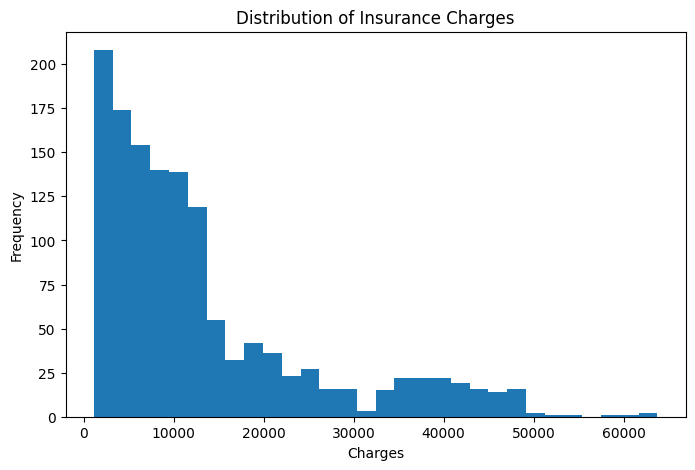

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

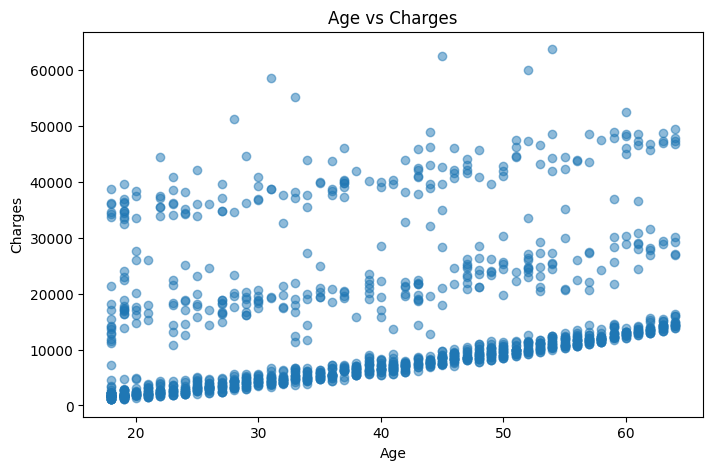

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["charges"], alpha=0.5)
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

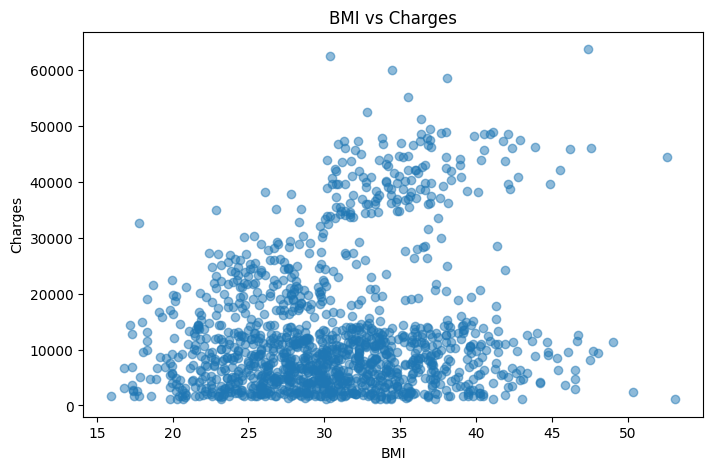

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df["bmi"], df["charges"], alpha=0.5)
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

In [29]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

In [32]:
from sklearn.model_selection import train_test_split

X = df[["age", "bmi", "children", "smoker"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print(X_train.shape)
print(X_test.shape)

(1070, 4)
(268, 4)


In [34]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

print("\nOriginal Features Shape :", X_train.shape)
print("Polynomial Features Shape :", X_train_poly.shape)


Original Features Shape : (1070, 4)
Polynomial Features Shape : (1070, 14)


In [35]:
model = LinearRegression()

model.fit(
    X_train_poly,
    y_train
)

LinearRegression()

In [36]:
y_pred = model.predict(
    X_test_poly
)

In [37]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", round(mae,2))

print("MSE :", round(mse,2))

print("RMSE :", round(rmse,2))

print("R² Score :", round(r2,4))

MAE : 2773.57
MSE : 20641401.66
RMSE : 4543.28
R² Score : 0.867


In [38]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred.round(2)
})
print(comparison.head(20))

    Actual Charges  Predicted Charges
0       9095.06825            9976.73
1       5272.17580            6257.84
2      29330.98315           34770.54
3       9301.89355           10831.36
4      33750.29180           29477.96
5       4536.25900            5637.46
6       2117.33885            2956.67
7      14210.53595           15838.02
8       3732.62510            3067.10
9      10264.44210           12023.00
10     18259.21600           20889.77
11      7256.72310            9243.66
12      3947.41310            5833.67
13     46151.12450           50283.26
14     48673.55880           53036.83
15     44202.65360           46114.84
16      9800.88820           10718.23
17     42969.85270           42715.94
18      8233.09750            9830.11
19     21774.32215           26826.09


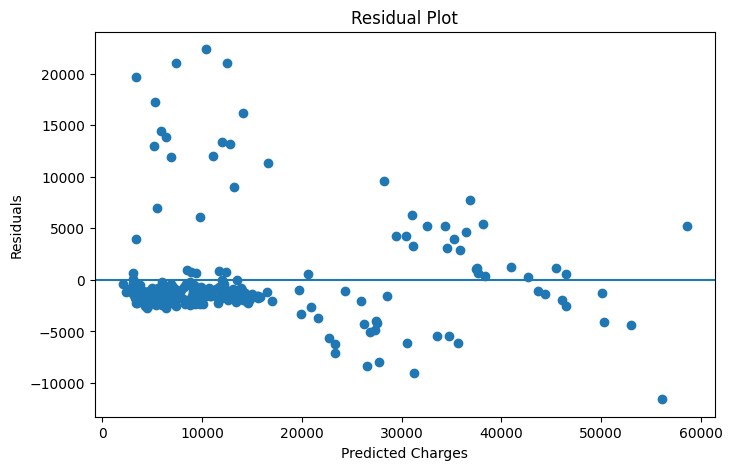

In [39]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0
)

plt.title("Residual Plot")

plt.xlabel("Predicted Charges")

plt.ylabel("Residuals")

plt.show()

In [40]:
print("\n===== ENTER CUSTOMER DETAILS =====")

age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
children = int(input("Enter Number of Children: "))
smoker = int(input("Smoker? (1 = Yes, 0 = No): "))

user_data = pd.DataFrame(
    [[age, bmi, children, smoker]],
    columns=[
        "age",
        "bmi",
        "children",
        "smoker"
    ]
)

user_poly = poly.transform(
    user_data
)

prediction = model.predict(
    user_poly
)

print(
    f"\nEstimated Insurance Cost = ${prediction[0]:,.2f}"
)


===== ENTER CUSTOMER DETAILS =====
Enter Age: 50
Enter BMI: 20
Enter Number of Children: 2
Smoker? (1 = Yes, 0 = No): 0

Estimated Insurance Cost = $10,653.33


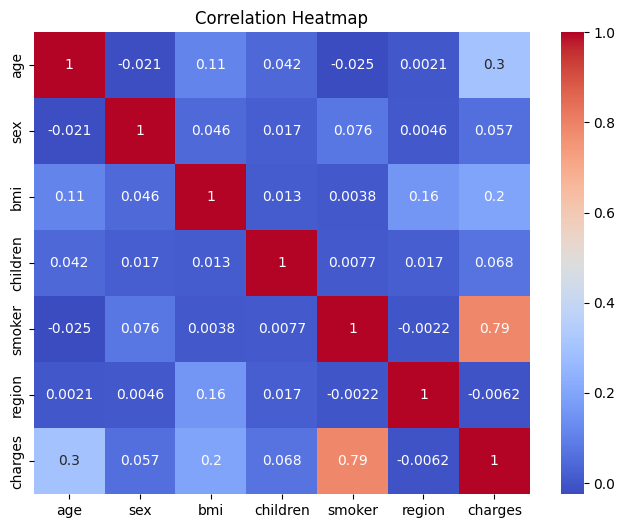

In [41]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

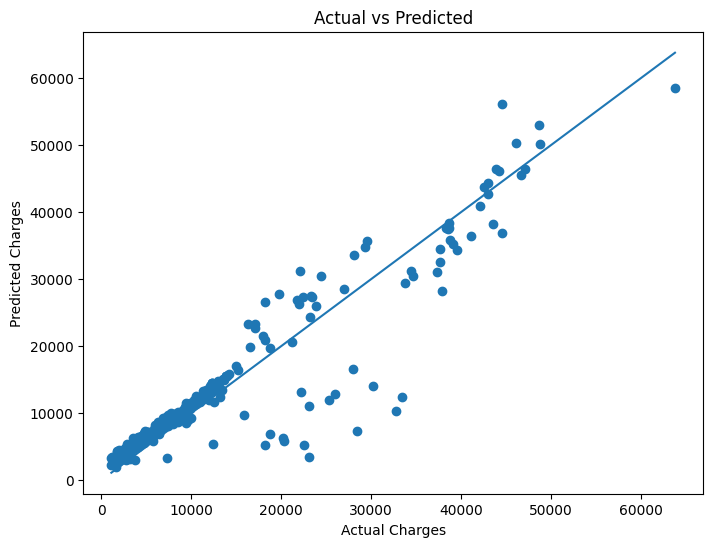

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")

plt.show()

In [43]:
feature_names = poly.get_feature_names_out(
    X.columns
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
10,bmi smoker,1446.343832
2,children,1208.815584
1,bmi,505.468577
7,age smoker,7.446934
4,age^2,4.052372
9,bmi children,1.165868
5,age bmi,1.138881
6,age children,-4.067148
8,bmi^2,-8.719302
0,age,-93.362099
